<a href="https://colab.research.google.com/github/K-Tanaka8/time_series_eda_demand_forecast/blob/main/time_series_eda_sample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [142]:
# 1 ライブラリ
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

In [143]:
# 2 データ読み込み
np.random.seed(42)

dates = pd.date_range(start="2023-01-01", periods=180)

sales = (
    50
    + 0.2 * np.arange(180)
    + 10 * np.sin(np.arange(180)/7)
    + np.random.normal(0,3,180)
)

df = pd.DataFrame({
    "date": dates,
    "sales": sales
})

df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")

df.head()

,sales
date,
2023-01-01,51.490142
2023-01-02,51.208924
2023-01-03,55.161494
2023-01-04,59.324808
2023-01-05,55.505882


In [144]:
# 3 データ概要
print("Shape:", df.shape)
print()

print("Data types")
print(df.dtypes)
print()

print("Missing values")
print(df.isna().sum())
print()

print(df.describe())

Shape: (180, 1)

Data types
sales    float64
dtype: object

Missing values
sales    0
dtype: int64

            sales
count  180.000000
mean    67.882136
std     12.053933
min     43.119971
25%     58.796225
50%     67.961886
75%     76.615458
max     98.208022


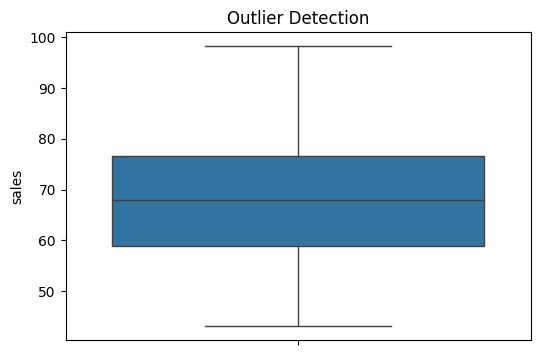

In [145]:
# 4 外れ値チェック
fig, ax = plt.subplots(figsize=(6,4))

sns.boxplot(y=df["sales"], ax=ax)

ax.set_title("Outlier Detection")
plt.show()

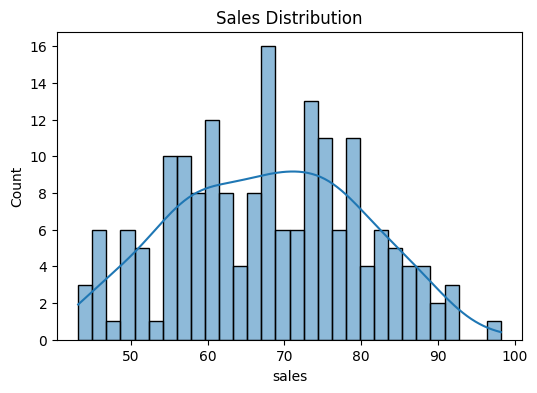

In [146]:
# 5 分布確認
fig, ax = plt.subplots(figsize=(6,4))

sns.histplot(df["sales"], bins=30, kde=True, ax=ax)

ax.set_title("Sales Distribution")

plt.show()

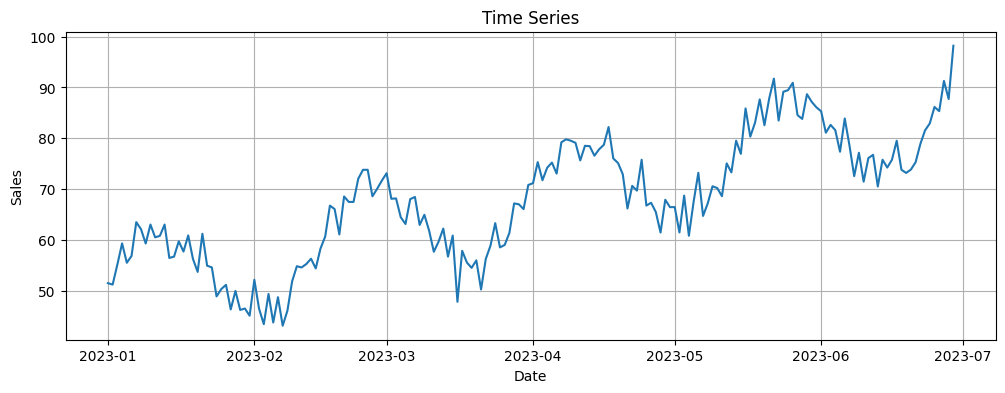

In [147]:
# 6 時系列プロット
fig, ax = plt.subplots(figsize=(12,4))

ax.plot(df.index, df["sales"])

ax.set_title("Time Series")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")

ax.grid(True)

plt.show()

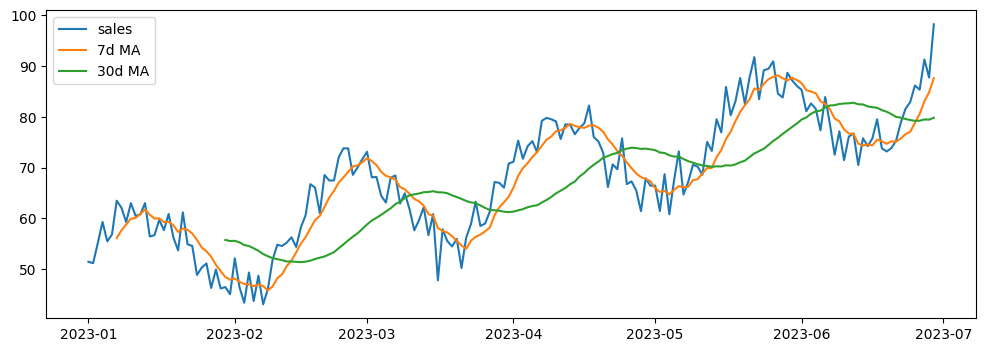

In [148]:
# 7 移動平均
df["rolling7"] = df["sales"].rolling(7).mean()
df["rolling30"] = df["sales"].rolling(30).mean()

fig, ax = plt.subplots(figsize=(12,4))

ax.plot(df.index, df["sales"], label="sales")
ax.plot(df.index, df["rolling7"], label="7d MA")
ax.plot(df.index, df["rolling30"], label="30d MA")

ax.legend()

plt.show()

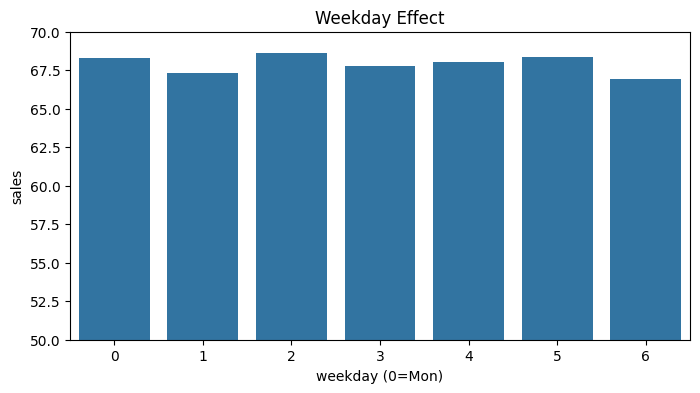

In [149]:
# 8 曜日分析
df["weekday"] = df.index.dayofweek

weekday_sales = df.groupby("weekday")["sales"].mean()

fig, ax = plt.subplots(figsize=(8,4))

sns.barplot(
    x=weekday_sales.index,
    y=weekday_sales.values,
    ax=ax
)

ax.set_title("Weekday Effect")
ax.set_xlabel("weekday (0=Mon)")
ax.set_ylabel("sales")

ax.set_ylim(50, 70)

plt.show()

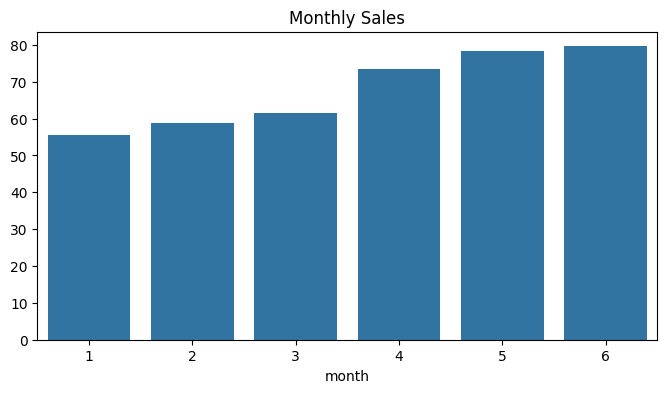

In [150]:
# 9 月別分析
df["month"] = df.index.month

month_sales = df.groupby("month")["sales"].mean()

fig, ax = plt.subplots(figsize=(8,4))

sns.barplot(
    x=month_sales.index,
    y=month_sales.values,
    ax=ax
)

ax.set_title("Monthly Sales")

plt.show()

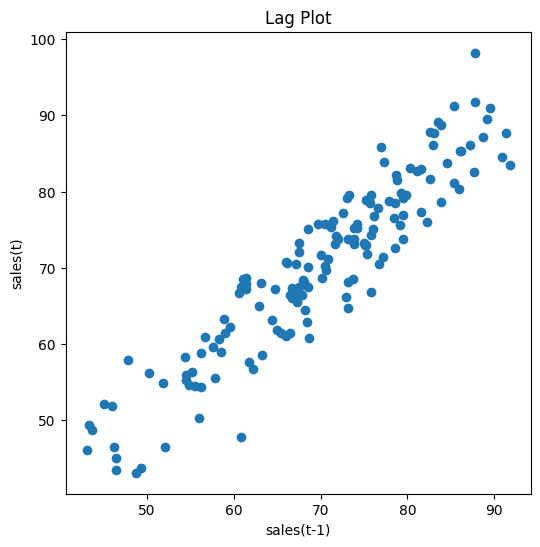

In [151]:
# 10 ラグ分析
df["lag1"] = df["sales"].shift(1)

lag_df = df.dropna()

fig, ax = plt.subplots(figsize=(6,6))

ax.scatter(
    lag_df["lag1"],
    lag_df["sales"]
)

ax.set_xlabel("sales(t-1)")
ax.set_ylabel("sales(t)")

ax.set_title("Lag Plot")

plt.show()

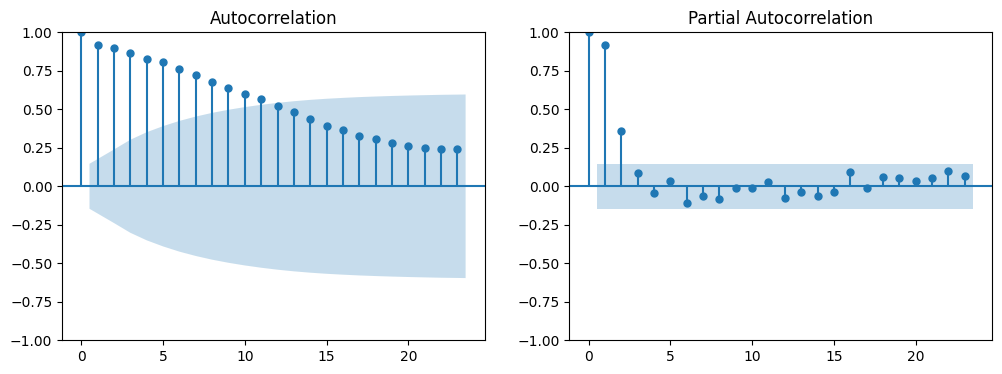

In [152]:
# 11 ACF / PACF
fig, ax = plt.subplots(1,2, figsize=(12,4))

plot_acf(df["sales"], ax=ax[0])
plot_pacf(df["sales"], ax=ax[1])

plt.show()

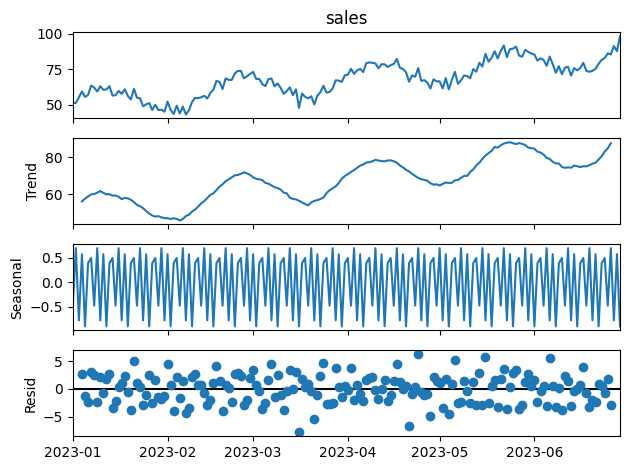

In [153]:
# 12 季節分解
result = seasonal_decompose(
    df["sales"],
    model="additive",
    period=7
)

result.plot()

plt.show()

In [154]:
# 13 定常性チェック（ADF検定）
result = adfuller(df["sales"])

print("ADF statistic:", result[0])
print("p-value:", result[1])

# p < 0.05 → stationary
# p > 0.05 → non-stationary

ADF statistic: -1.677634739360764
p-value: 0.4426710016157359


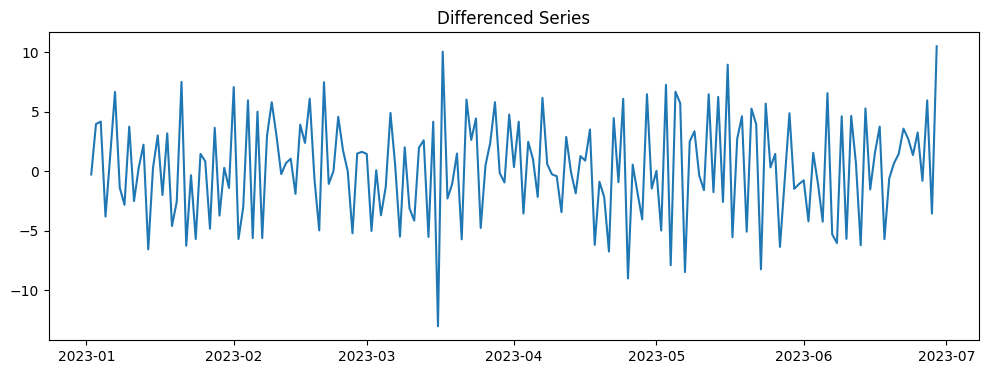

In [155]:
# 14 差分
df["diff"] = df["sales"].diff()

fig, ax = plt.subplots(figsize=(12,4))

ax.plot(df["diff"])

ax.set_title("Differenced Series")

plt.show()

In [156]:
# 15 定常性チェック（トレンドありADF検定）
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["sales"], regression="ct")

print("ADF:", result[0])
print("p-value:", result[1])

ADF: -7.055670686984738
p-value: 1.0568937874431502e-08


In [157]:
# 16 EDAまとめ（重要）
'''
・売上は上昇トレンドあり
・週次seasonalityあり
・weekday effectあり
・外れ値なし
・non-stationary
・約7日周期の季節性あり
・曜日による売上差あり
・自己相関あり（売上は前日の売上と正の相関を持つ）
・PACF（偏自己相関）　ラグ1強く、AR(1)の可能性あり
・p < 0.05→定常
・ADF：トレンドあり　による定常性チェック　p > 0.05→非定常

'''

'\n・売上は上昇トレンドあり\n・週次seasonalityあり\n・weekday effectあり\n・外れ値なし\n・non-stationary\n・約7日周期の季節性あり\n・曜日による売上差あり\n・自己相関あり（売上は前日の売上と正の相関を持つ）\n・PACF（偏自己相関）\u3000ラグ1強く、AR(1)の可能性あり\n・p < 0.05→定常\n・ADF：トレンドあり\u3000による定常性チェック\u3000p > 0.05→非定常\n\n'